In [19]:
%matplotlib inline
%run -i setupMatplotlib.py

In [20]:
import os

projectDir = os.environ['PLATO_PROJECT_HOME']
workDir = os.environ['PLATO_WORKDIR']

%run -i setupEnvironment.py

In [21]:
import numpy as np

In [22]:
from imp import reload
import simfile
reload(simfile)
from simfile import SimFile

In [23]:
simFile = SimFile(workDir + '/Run01.hdf5')

### API of SimFile

Request image, bias and smearing maps
```
img = simFile.getImage(<Exposure Nr>)
biasMap = simFile.getBiasMap(<Exposure Nr>)
smearingMap = simFile.getSmearingMap(<Exposure Nr>)

subPixelImage = simFile.getSubPixelImage(<Exposure Nr>)
```

Request smaller imagettes around a star position
```
im = simFile.getImagette(11632, 9, radius = 3)
```

Request star information
```
starIDs, RA, dec, Vmag, xFPmm, yFPmm, rowPix, colPix = simFile.getStarCatalog()
ID, row, col, Xmm, Ymm = simFile.getStarCoordinates(<Exposure Nr> [, minVmag=<Vmag>, maxVmag=<Vmag>])
```

Request Input Parameters
```
value = simFifle.getInputParameter(<groupName>, <parameterName>)
```

Request the Flatfield maps
```
prnu = simFile.getPRNU()
irnu = simFile.getIRNU()
```

Request the PSF
```
psf = simFile.getPsf("rebinnedPSFimage")
```

Request Platform information
```
RA, dec = simFile.getPlatformPointingCoordinates()
yaw, pitch, roll = simFile.getYawPitchRoll()
```

Reloading the HDF5 file
```
simFile.reload()
```

In [24]:
img0 = simFile.getImage(0)

In [25]:
bm0 = simFile.getBiasMap(0)
sm0 = simFile.getSmearingMap(0)

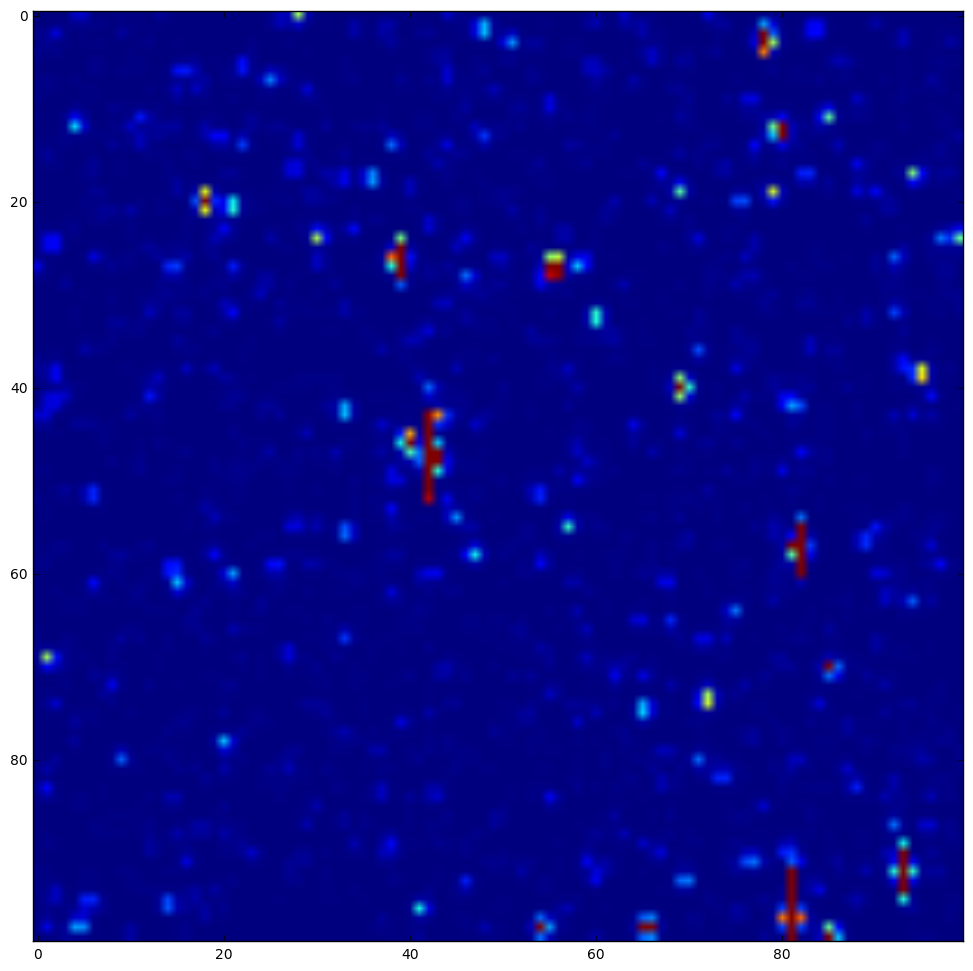

In [26]:
plt.imshow(img0)

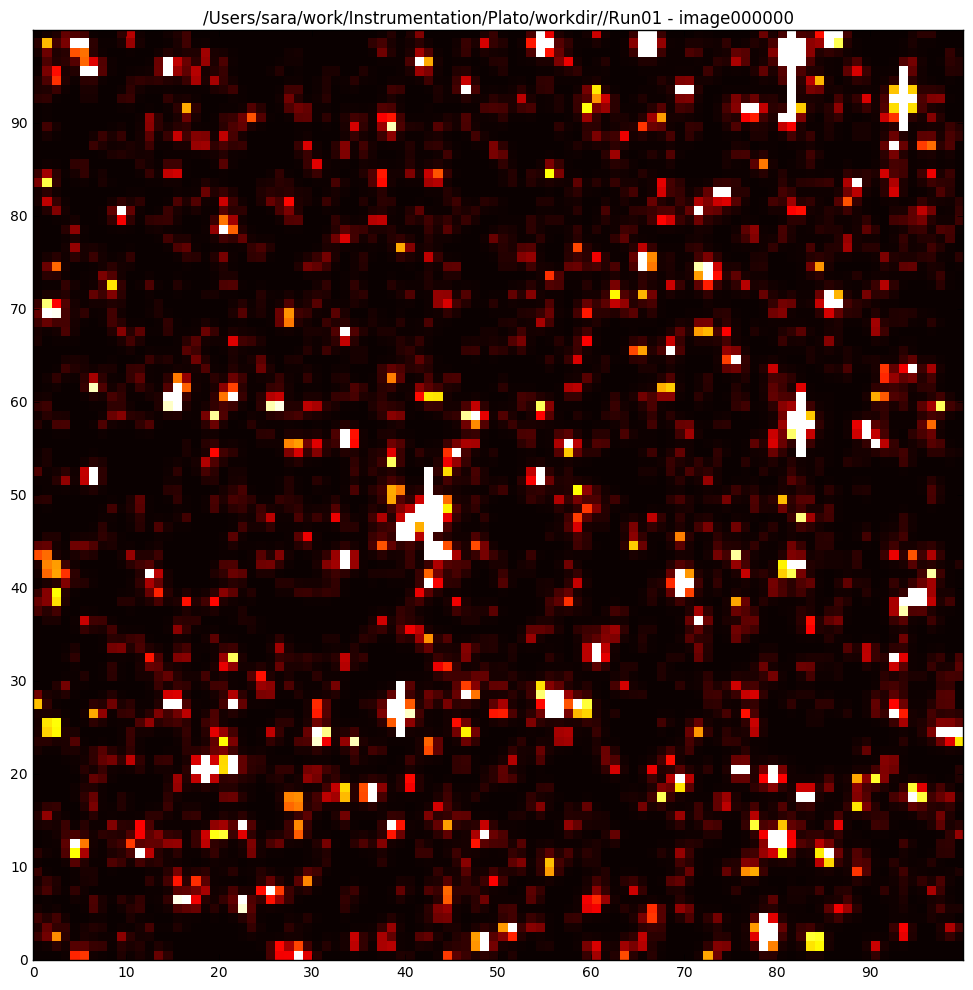

In [27]:
simFile.showImage(0)

In [28]:
subPixelImage = simFile.getSubPixelImage(9)

Error: SimFile.getSubPixelImage(): there is no SubPixelImages group in the HDF5 file


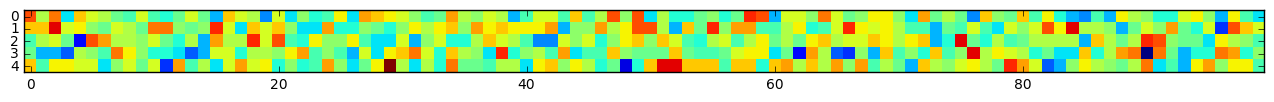

In [29]:
plt.imshow(bm0, interpolation='nearest')

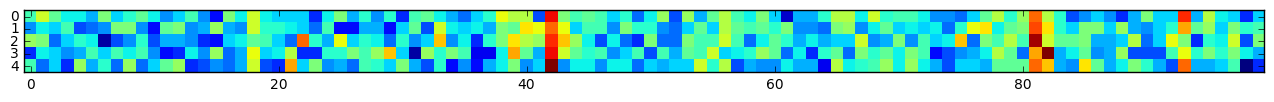

In [30]:
plt.imshow(sm0, interpolation='nearest')

In [31]:
starIDs = simFile.getStarCoordinates(9, minVmag = None, maxVmag = None)[0]
print(starIDs)

[15553 15556 15563 ..., 25926 25936 25945]


In [32]:
imagette = simFile.getImagette(15563, 9, radius = 3)
#imagette = simFile.getImagette(11632, 9, radius = 3)

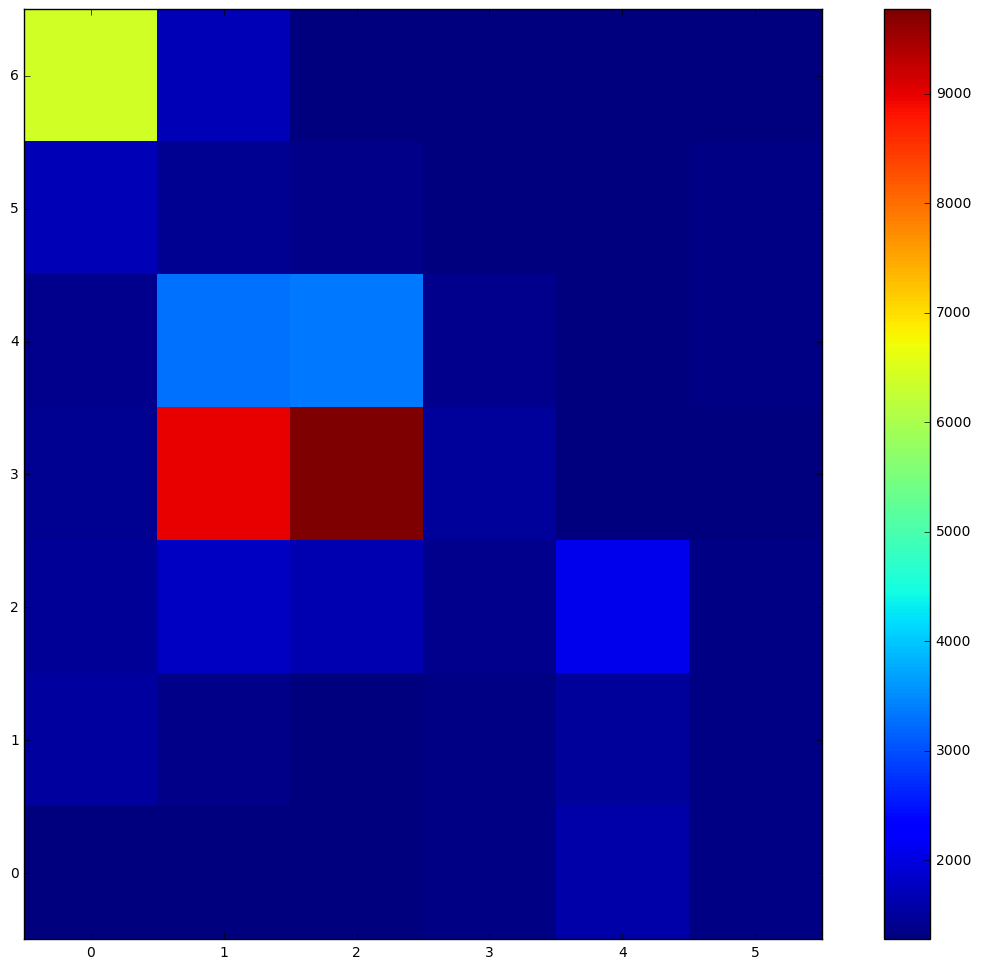

In [33]:
plt.imshow(imagette, interpolation='nearest', origin='lower')
plt.colorbar()

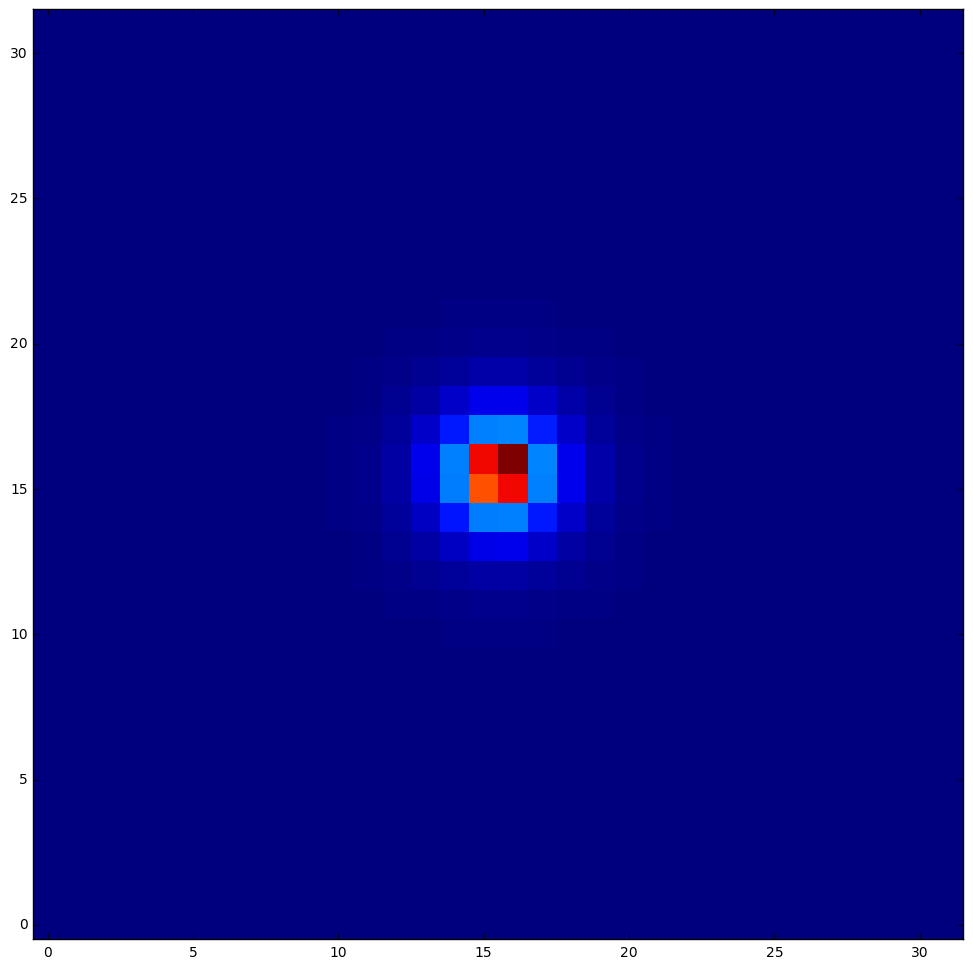

In [34]:
psf = simFile.getPsf("rebinnedPSFsubPixel")
plt.imshow(psf, interpolation='nearest', origin='lower')

In [35]:
starIDs, RA, dec, Vmag, xFPmm, yFPmm, rowPix, colPix = simFile.getStarCatalog()

In [36]:
"starIDs[{}] = {}".format(len(starIDs), starIDs)

'starIDs[1874] = [15553 15556 15563 ..., 25970 25972 25974]'

In [37]:
print("RA[{}] = {}".format(len(RA), RA))
print("Dec[{}] = {}".format(len(dec), dec))
print("Vmag[{}] = {}".format(len(Vmag), Vmag))

RA[1874] = [ 179.757343  179.766831  179.793092 ...,  180.151979  180.162209
  180.163419]
Dec[1874] = [-69.917961 -69.905678 -69.921272 ..., -69.493408 -69.481102 -69.493965]
Vmag[1874] = [ 11.742  13.201  10.564 ...,  14.545  14.345  14.045]


In [38]:
print("xFPmm[{}] = {}".format(len(xFPmm), xFPmm))
print("yFPmm[{}] = {}".format(len(yFPmm), yFPmm))

xFPmm[1874] = [ 0.01115747  0.06194539  0.03866363 ...,  1.85486643  1.90727003
  1.86555231]
yFPmm[1874] = [ 0.53165992  0.55963229  0.48039645 ...,  1.41280896  1.43942285
  1.39767888]


In [39]:
print("rowPix[{}] = {}".format(len(rowPix), rowPix))
print("colPix[{}] = {}".format(len(colPix), colPix))

rowPix[1874] = [ 29.53666231  31.09068264  26.68869173 ...,  78.48938648  79.96793637
  77.64882654]
colPix[1874] = [   0.61985958    3.44141048    2.14797937 ...,  103.04813486  105.95944609
  103.64179495]


To get the coordinates of all stars within a magnitude range [minVmag, maxVmag] in image 10.

In [40]:
starID, row, col, Xmm, Ymm = simFile.getStarCoordinates(9, minVmag=6.0, maxVmag=12.0)

In [41]:
"starID[{}] = {}".format(len(starID), starID)

'starID[161] = [15553 15563 15575 15619 15636 15650 15651 15664 15680 15704 15709 15725\n 15733 17583 17607 17614 17623 17641 17656 17708 17713 17726 17741 17748\n 17752 17759 17766 17769 17772 17777 17780 17783 17796 17798 17801 17806\n 17808 17811 17815 17832 17843 17884 17889 17894 19587 19613 19619 19638\n 19654 19686 19692 19700 19711 19713 19729 19731 19751 19761 19772 19796\n 19803 19805 19810 19811 19816 19827 19830 19831 19846 19855 19875 19909\n 19928 19940 19946 19952 19960 19963 19966 19993 20006 20009 20021 20022\n 20038 20047 20048 20065 20068 20070 20086 20089 20095 20099 20113 20130\n 21659 21686 21724 21728 21736 21763 21776 21839 21856 21861 21864 21882\n 21890 21897 21899 21900 21915 21923 21962 21971 21993 21996 22000 22006\n 22011 22018 22022 22024 22050 22076 22087 22101 22102 22114 22123 22126\n 23791 23833 23836 23844 23860 23861 23887 23890 23914 23915 23917 23918\n 23926 23936 23941 23960 23972 23984 23994 24032 24040 24043 24051 24063\n 25856 25858 25888 2590

In [42]:
simFile.getInputParameter("ObservingParameters", "NumExposures")

10

In [43]:
%matplotlib qt
%run -i setupMatplotlib.py

In [44]:
#fig = simFile.showImage(9)
#ID, row, col, Xmm, Ymm = simFile.getStarCoordinates(9)

#axis = fig.axes[0]
#axis.scatter(np.floor(col), np.floor(row), marker='x', c='g')

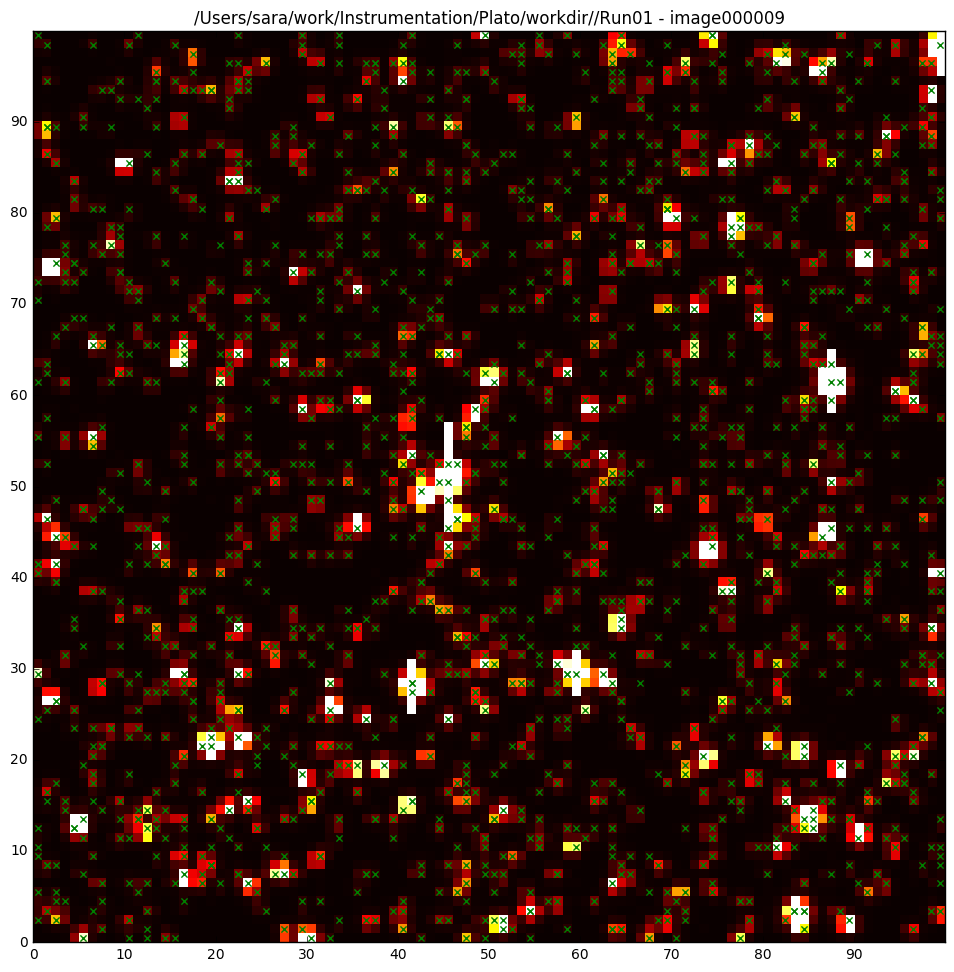

In [45]:
fig = simFile.showImage(9)
ID, row, col, Xmm, Ymm = simFile.getStarCoordinates(9)
plt.scatter(np.floor(col)+0.5, np.floor(row)+0.5, marker='x', c='g')

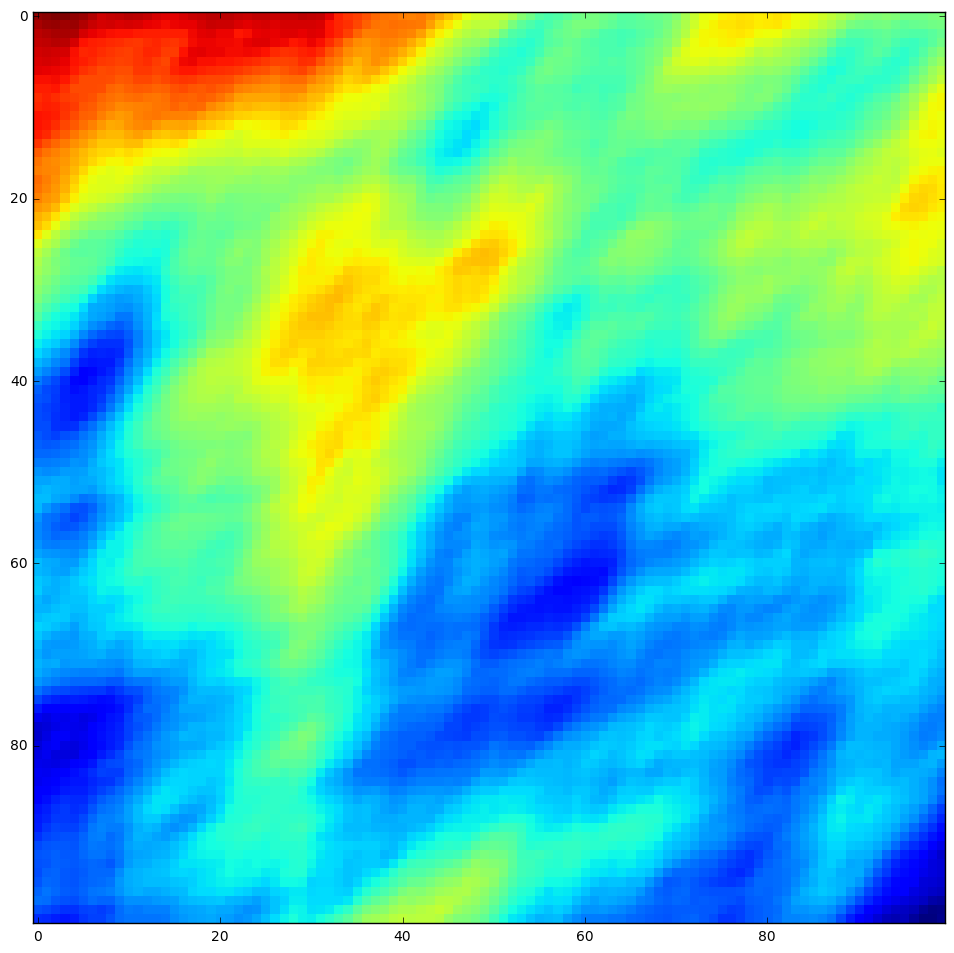

In [46]:
prnu = simFile.getPRNU()
plt.imshow(prnu, interpolation='nearest')

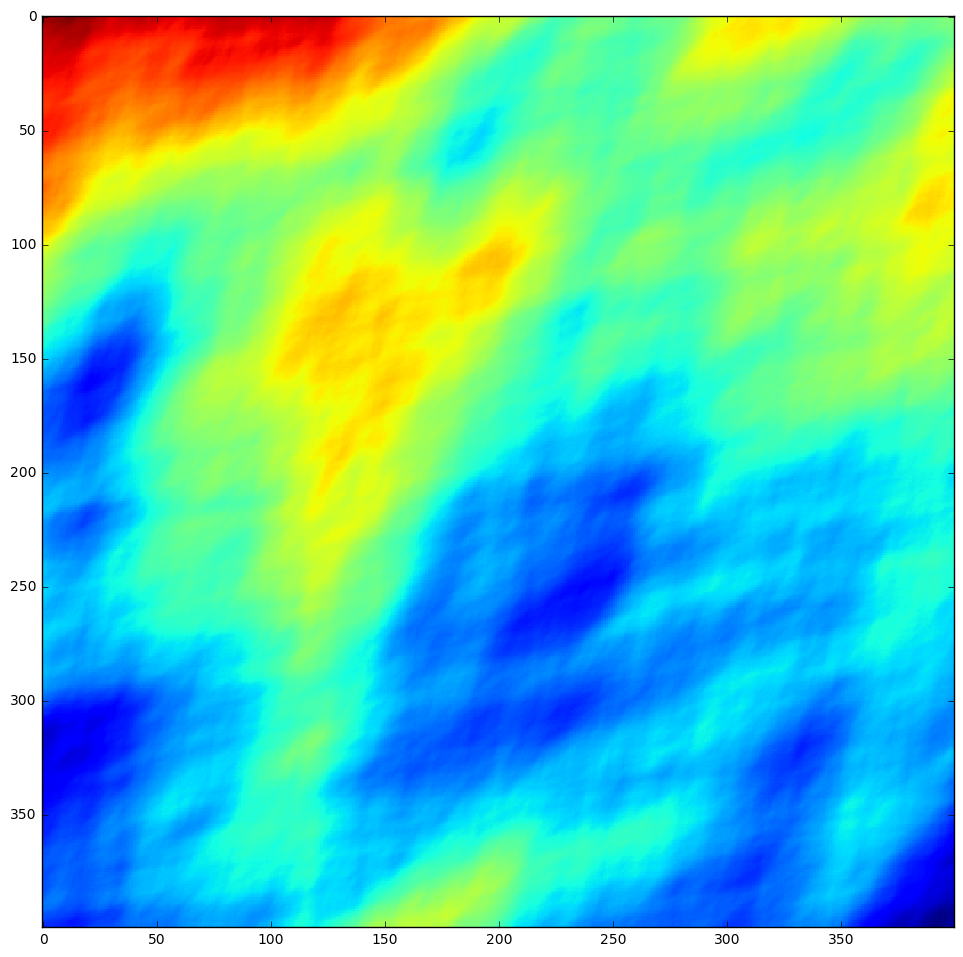

In [47]:
irnu = simFile.getIRNU()
plt.imshow(irnu, interpolation='nearest')

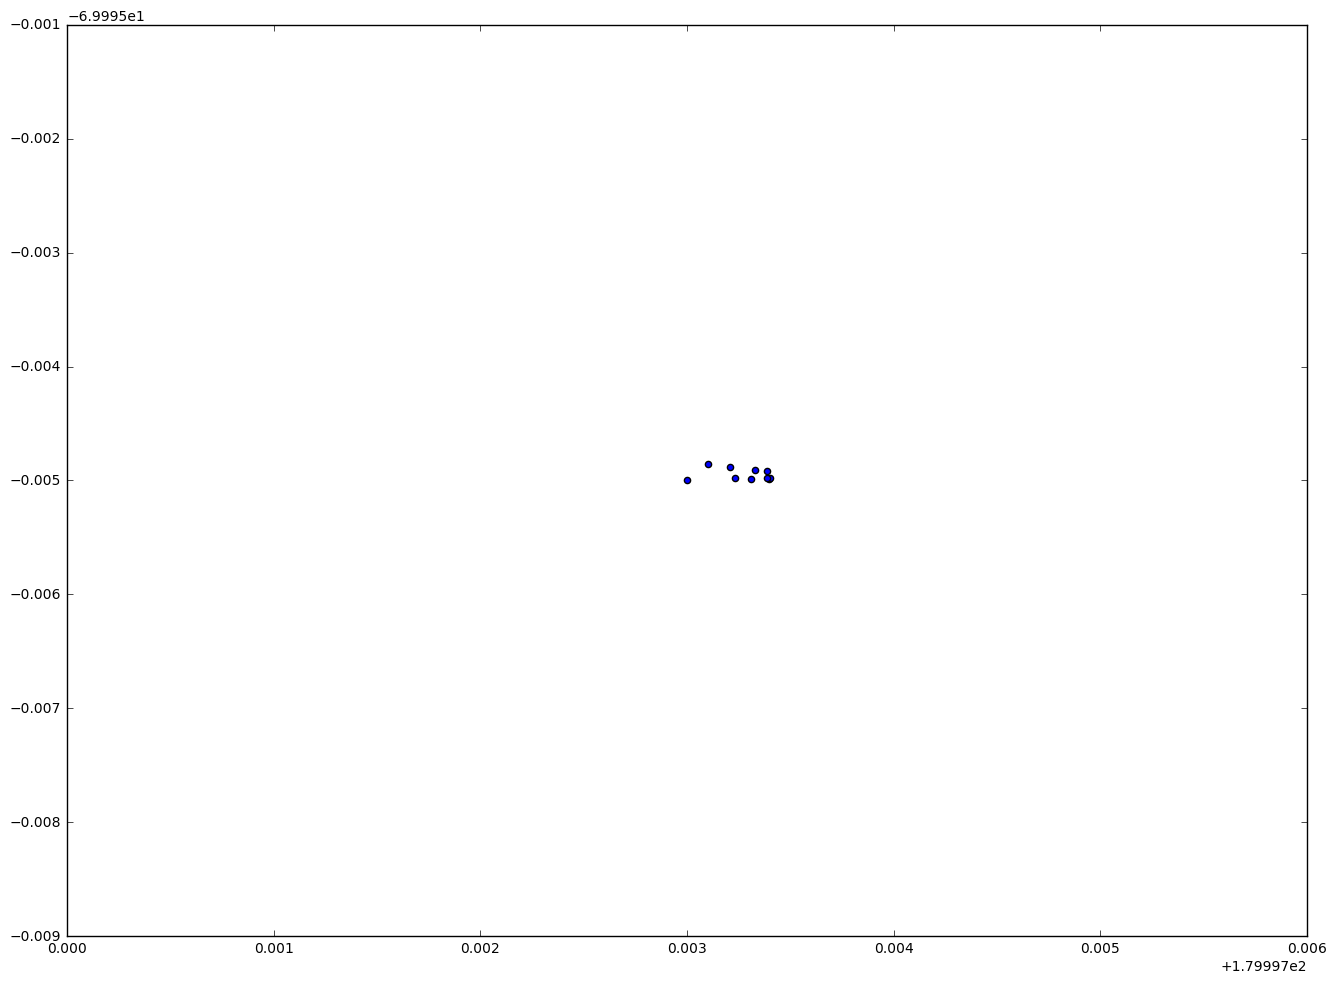

In [48]:
RA, dec = simFile.getPlatformPointingCoordinates()
plt.scatter(RA, dec)

In [49]:
yaw, pitch, roll = simFile.getYawPitchRoll()

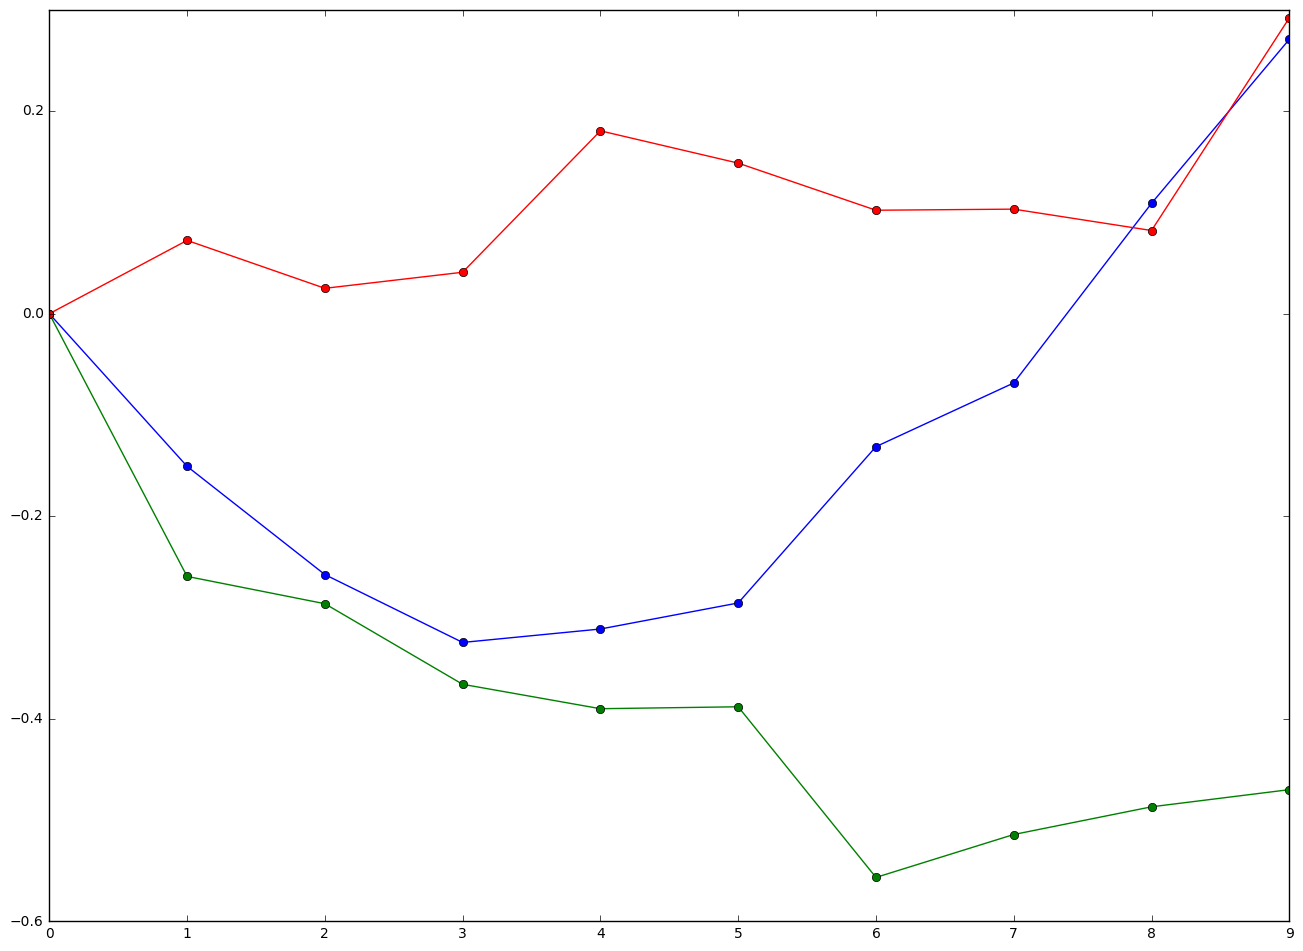

In [50]:
plt.plot(yaw, '-o')
plt.plot(pitch, '-o')
plt.plot(roll, '-o')